In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

Renomeando as colunas e colocando a coluna resultado como 'class'

In [ ]:
columns = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class']
df = pd.read_csv("magic04.data", names = columns)
df

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g
...,...,...,...,...,...,...,...,...,...,...,...
19015,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258,h
19016,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560,h
19017,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166,h
19018,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166,h


Colocando g = 1 e h = 0 (binário)

In [ ]:
df["class"] = (df["class"] == "g").astype(int)

In [ ]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


Plotar os gráficos pra cada categoria

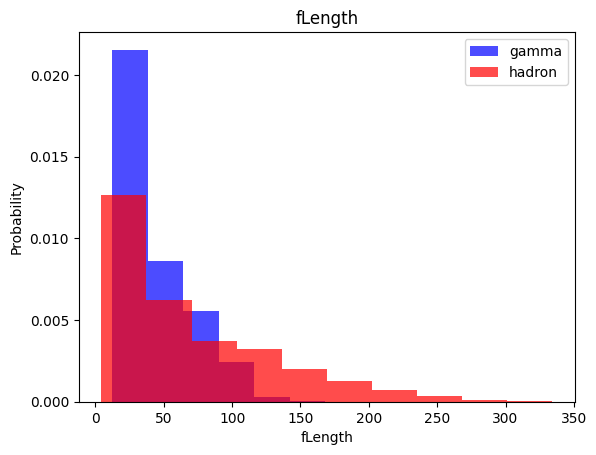

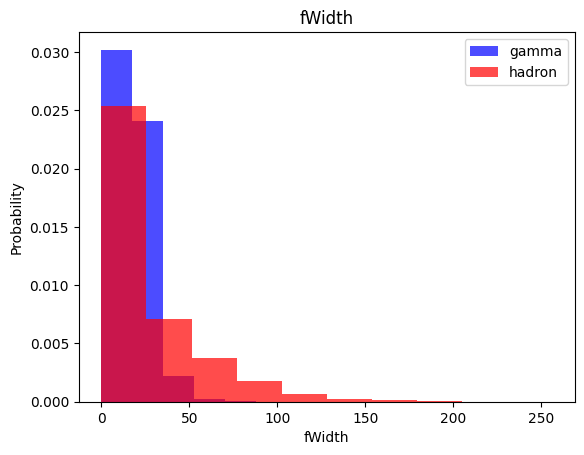

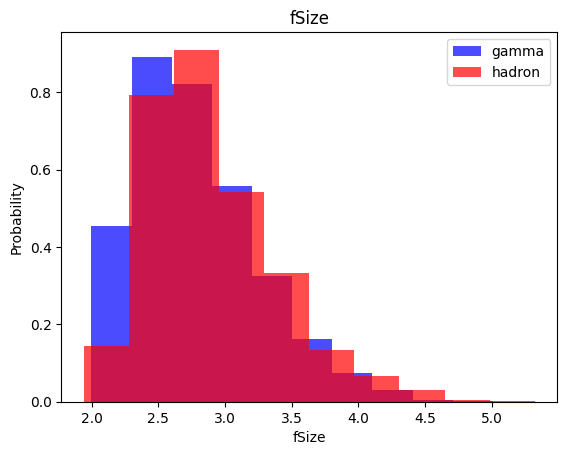

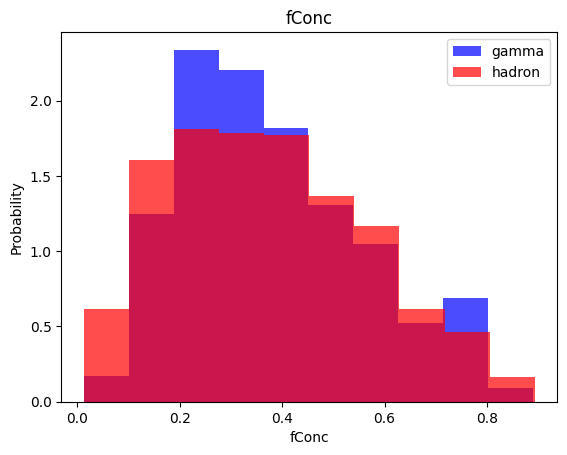

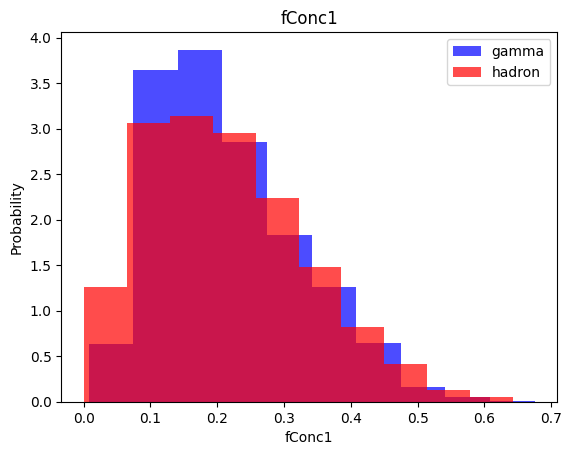

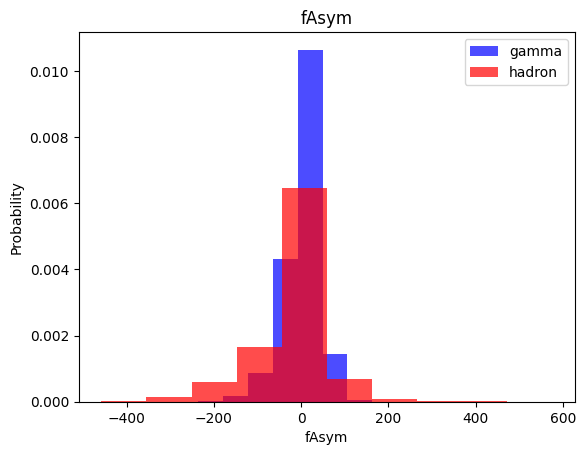

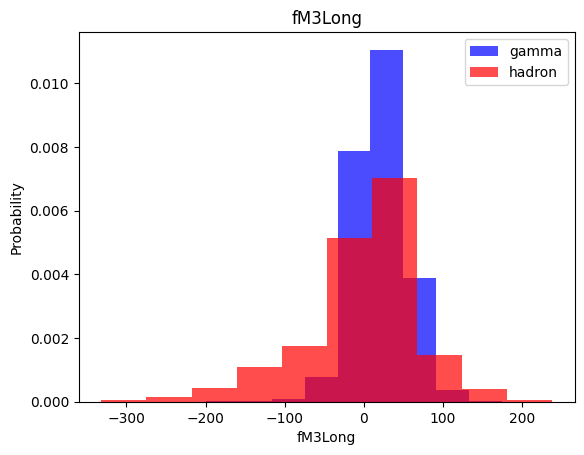

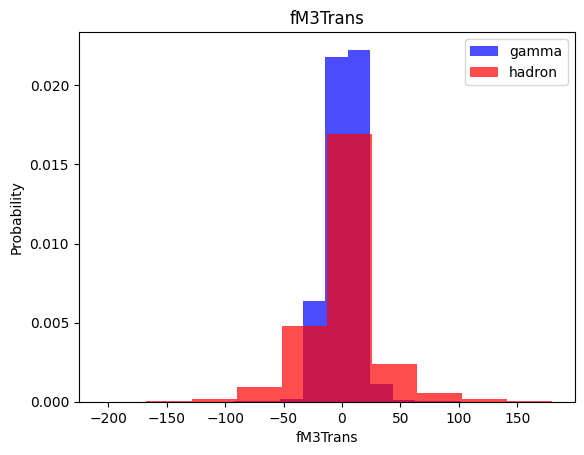

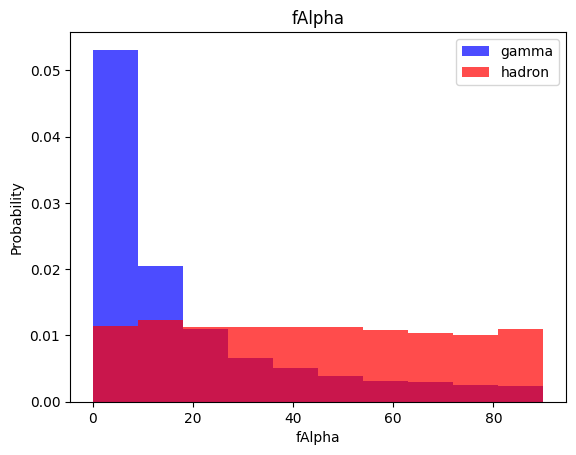

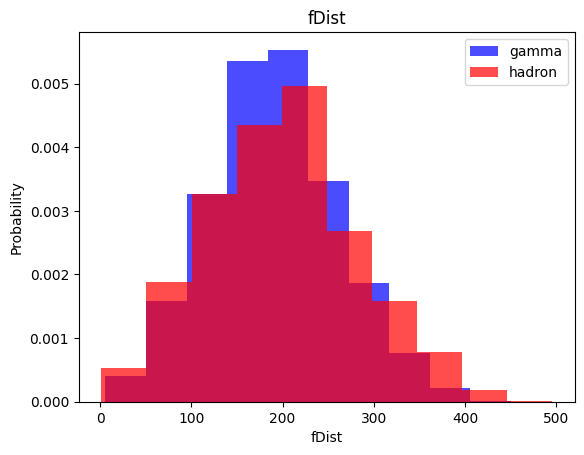

In [ ]:
for label in columns[:-1]:
  plt.hist(df[df["class"] == 1][label], color = 'blue', label = 'gamma', alpha = 0.7, density = True )
  plt.hist(df[df["class"] == 0][label], color = 'red', label = 'hadron', alpha = 0.7, density = True)
  plt.title(label)
  plt.ylabel("Probability")
  plt.xlabel(label)
  plt.legend()
  plt.show()

Train, Validation and Test datasets

In [ ]:
train, valid, test = np.split(df.sample(frac = 1), [int(0.6*len(df)), int(0.8*len(df))])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [ ]:
print(len(train[train["class"] == 0]))
print(len(train[train["class"] == 1]))

4009
7403


In [ ]:
def scale_dataset(dataframe, oversample = False):
  X = dataframe[dataframe.columns[:-1]].values
  y = dataframe[dataframe.columns[-1]].values

  scaler = StandardScaler()
  X = scaler.fit_transform(X)
  #Oversample para o valor de y == 0 muito menor que y == 1. Equilibrando os dados
  if oversample:
    ros = RandomOverSampler()
    X, y = ros.fit_resample(X, y)

  data = np.hstack((X, np.reshape(y, (-1, 1))))

  return data, X, y

Como valid e test são mais para testes então não é necessário o oversample para eles. Pelo menos não por enquanto

In [ ]:
train, X_train, y_train = scale_dataset(train, oversample = True)
valid, X_valid, y_valid = scale_dataset(valid, oversample = False)
test, X_test, y_test = scale_dataset(test, oversample = False)

#kNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn_model.predict(X_test)

In [ ]:
print(y_pred)

[0 0 1 ... 1 0 1]


Precisão - De todos os que previ como sendo 0, quais realmente eram 0

Recall - De todos os 0 do dataset, quantos eu previ corretamente

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.73      0.73      1371
           1       0.85      0.86      0.85      2433

    accuracy                           0.81      3804
   macro avg       0.80      0.79      0.79      3804
weighted avg       0.81      0.81      0.81      3804



##Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
nb_model = GaussianNB()
nb_model = nb_model.fit(X_train, y_train)

In [ ]:
y_pred = nb_model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.40      0.51      1371
           1       0.73      0.91      0.81      2433

    accuracy                           0.72      3804
   macro avg       0.72      0.65      0.66      3804
weighted avg       0.72      0.72      0.70      3804



## Log Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(X_train, y_train)

In [ ]:
y_pred = lg_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.71      0.70      1371
           1       0.83      0.82      0.83      2433

    accuracy                           0.78      3804
   macro avg       0.76      0.77      0.77      3804
weighted avg       0.78      0.78      0.78      3804



# SVM

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_model = SVC()
svm_model = svm_model.fit(X_train, y_train)

In [ ]:
y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.78      0.80      1371
           1       0.88      0.90      0.89      2433

    accuracy                           0.86      3804
   macro avg       0.85      0.84      0.84      3804
weighted avg       0.86      0.86      0.86      3804



In [ ]:
y_pred_knn = knn_model.predict(X_test)
knn_report = classification_report(y_test, y_pred_knn, output_dict=True)

# Extract metrics for class '0'
precision_0_knn = knn_report['0']['precision']
recall_0_knn = knn_report['0']['recall']
f1_score_0_knn = knn_report['0']['f1-score']

# Extract metrics for class '1'
precision_1_knn = knn_report['1']['precision']
recall_1_knn = knn_report['1']['recall']
f1_score_1_knn = knn_report['1']['f1-score']

# Extract overall accuracy
accuracy_knn = knn_report['accuracy']

# Store metrics in a dictionary
knn_metrics = {
    'class_0': {
        'precision': precision_0_knn,
        'recall': recall_0_knn,
        'f1_score': f1_score_0_knn
    },
    'class_1': {
        'precision': precision_1_knn,
        'recall': recall_1_knn,
        'f1_score': f1_score_1_knn
    },
    'accuracy': accuracy_knn
}

print("KNN Metrics:")
print(knn_metrics)

KNN Metrics:
{'class_0': {'precision': 0.7429210134128167, 'recall': 0.7272064186725018, 'f1_score': 0.7349797272392186}, 'class_1': {'precision': 0.8480909829406986, 'recall': 0.8581997533908755, 'f1_score': 0.8531154239019407}, 'accuracy': 0.8109884332281808}


In [ ]:
y_pred_nb = nb_model.predict(X_test)
nb_report = classification_report(y_test, y_pred_nb, output_dict=True)

# Extract metrics for class '0'
precision_0_nb = nb_report['0']['precision']
recall_0_nb = nb_report['0']['recall']
f1_score_0_nb = nb_report['0']['f1-score']

# Extract metrics for class '1'
precision_1_nb = nb_report['1']['precision']
recall_1_nb = nb_report['1']['recall']
f1_score_1_nb = nb_report['1']['f1-score']

# Extract overall accuracy
accuracy_nb = nb_report['accuracy']

# Store metrics in a dictionary
nb_metrics = {
    'class_0': {
        'precision': precision_0_nb,
        'recall': recall_0_nb,
        'f1_score': f1_score_0_nb
    },
    'class_1': {
        'precision': precision_1_nb,
        'recall': recall_1_nb,
        'f1_score': f1_score_1_nb
    },
    'accuracy': accuracy_nb
}

print("Naive Bayes Metrics:")
print(nb_metrics)

Naive Bayes Metrics:
{'class_0': {'precision': 0.7036082474226805, 'recall': 0.3982494529540481, 'f1_score': 0.5086166744294365}, 'class_1': {'precision': 0.7275429326287979, 'recall': 0.9054665022605837, 'f1_score': 0.8068119392052737}, 'accuracy': 0.7226603575184016}


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

nb_model = GaussianNB()
nb_model = nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
nb_report = classification_report(y_test, y_pred_nb, output_dict=True)

# Extract metrics for class '0'
precision_0_nb = nb_report['0']['precision']
recall_0_nb = nb_report['0']['recall']
f1_score_0_nb = nb_report['0']['f1-score']

# Extract metrics for class '1'
precision_1_nb = nb_report['1']['precision']
recall_1_nb = nb_report['1']['recall']
f1_score_1_nb = nb_report['1']['f1-score']

# Extract overall accuracy
accuracy_nb = nb_report['accuracy']

# Store metrics in a dictionary
nb_metrics = {
    'class_0': {
        'precision': precision_0_nb,
        'recall': recall_0_nb,
        'f1_score': f1_score_0_nb
    },
    'class_1': {
        'precision': precision_1_nb,
        'recall': recall_1_nb,
        'f1_score': f1_score_1_nb
    },
    'accuracy': accuracy_nb
}

print("Naive Bayes Metrics:")
print(nb_metrics)

Naive Bayes Metrics:
{'class_0': {'precision': 0.7036082474226805, 'recall': 0.3982494529540481, 'f1_score': 0.5086166744294365}, 'class_1': {'precision': 0.7275429326287979, 'recall': 0.9054665022605837, 'f1_score': 0.8068119392052737}, 'accuracy': 0.7226603575184016}


#Neural Network

In [ ]:
import tensorflow as tf

In [ ]:
def plot_history(history):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 4))
  ax1.plot(history.history['loss'], label='loss')
  ax1.plot(history.history['val_loss'], label='val_loss')
  ax1.set_xlabel('Epoch')
  ax1.set_ylabel('Binary crossentropy')
  ax1.legend()
  ax1.grid(True)

  ax2.plot(history.history['accuracy'], label='accuracy')
  ax2.plot(history.history['val_accuracy'], label='val_accuracy')
  ax2.set_xlabel('Epoch')
  ax2.set_ylabel('Accuracy')
  ax2.legend()
  ax2.grid(True)

  plt.show()


In [ ]:
def train_model(X_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs):
  nn_model = tf.keras.Sequential([
      tf.keras.layers.Dense(num_nodes, activation = 'relu', input_shape = (10, )),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(num_nodes, activation = 'relu'),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(1, activation = 'sigmoid')
  ])

  nn_model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss = 'binary_crossentropy',
                  metrics = ['accuracy'])
  history = nn_model.fit(
    X_train, y_train, epochs = epochs, batch_size = batch_size, validation_split = 0.2, verbose = 0
  )

  return nn_model, history

- Interessante testar com mais camadas e testar outros modelos alem da rede neural. Mas precisa de mais dados para treinar o modelo.

#Grid Search

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


64 nodes, dropout 0, lr 0.001, batch_size 128, epochs 100


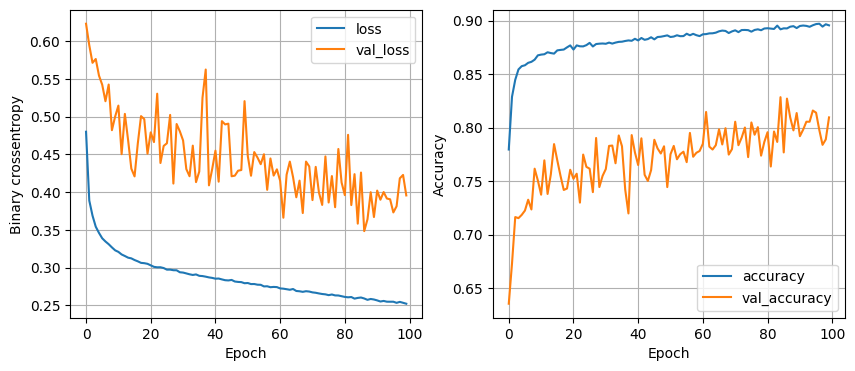

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8834 - loss: 0.2840
64 nodes, dropout 0, lr 0.0005, batch_size 128, epochs 100


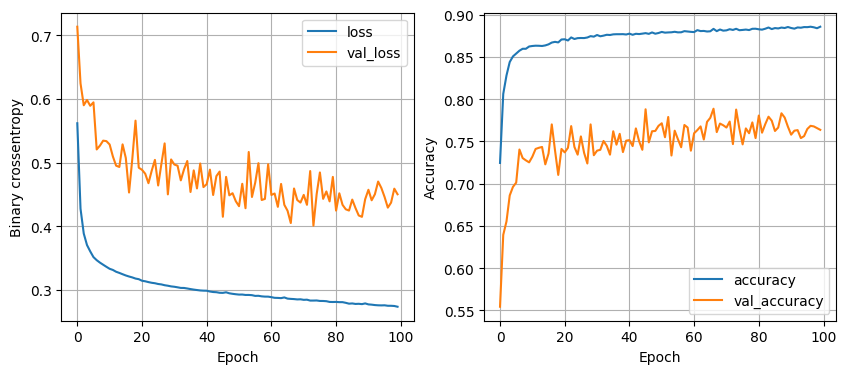

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8804 - loss: 0.2805
64 nodes, dropout 0, lr 0.0001, batch_size 128, epochs 100


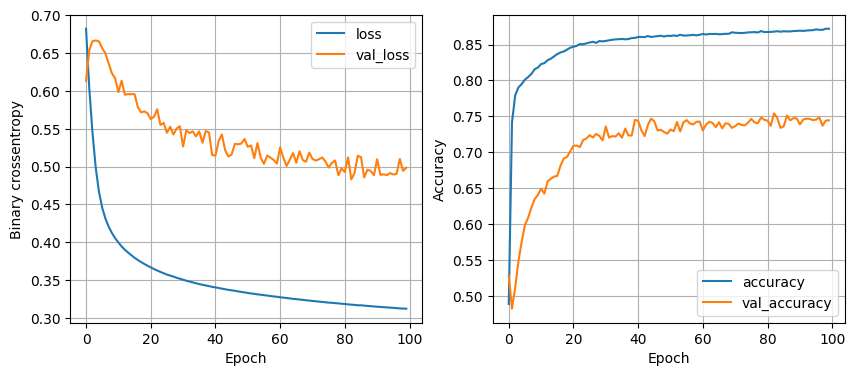

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8867 - loss: 0.2862
64 nodes, dropout 0.2, lr 0.001, batch_size 128, epochs 100


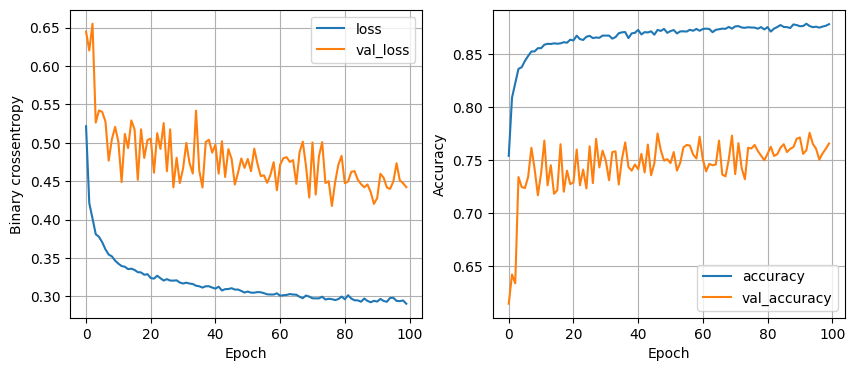

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8908 - loss: 0.2702
64 nodes, dropout 0.2, lr 0.0005, batch_size 128, epochs 100


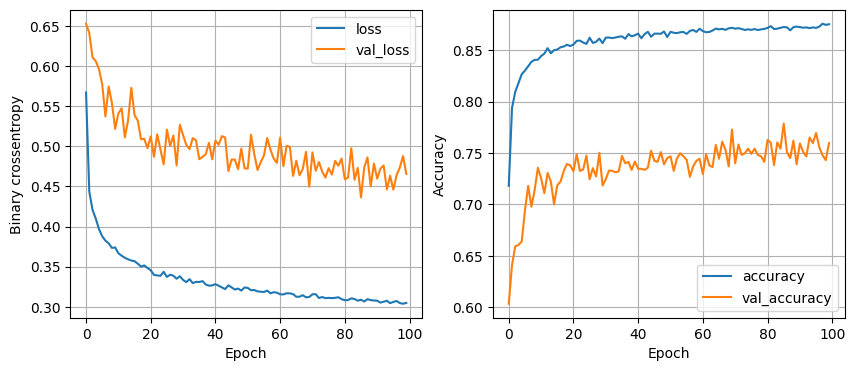

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8855 - loss: 0.2710
64 nodes, dropout 0.2, lr 0.0001, batch_size 128, epochs 100


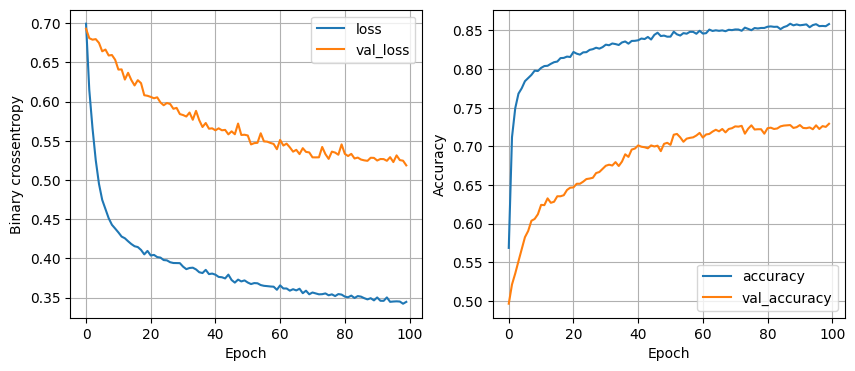

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8784 - loss: 0.3003


In [ ]:
least_val_loss = float('inf')
least_loss_model = None
epochs = 100
for num_nodes in [64]: #Fixo!(16, 32, 64) Número de neurônios por camada oculta (64 neurônios por camada)
  for dropout_prob in [0, 0.2]:#Prevenção de overfitting. Dropar neurônios aleatoriamente para o modelo não se escorar em nós específicos
    for lr in [0.001, 0.0005, 0.0001]:#0.001 ou menor
      for batch_size in [128]:#Fixo!(32, 64, 128)
        model, history = train_model(X_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs)
        print(f"{num_nodes} nodes, dropout {dropout_prob}, lr {lr}, batch_size {batch_size}, epochs {epochs}")
        plot_history(history)
        val_loss = model.evaluate(X_valid, y_valid)[0]
        if val_loss < least_val_loss:
          least_val_loss = val_loss
          least_loss_model = model

- Para binary_crossentropy essa loss ficou boa pois ela trata da discrepância entre as previsões do modelo e a probabilidade de acertos reais. Penaliza fortemente as previsões confiantes que estão erradas.

In [ ]:
y_pred = least_loss_model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).reshape(-1, )

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.74      0.80      1371
           1       0.86      0.94      0.90      2433

    accuracy                           0.87      3804
   macro avg       0.87      0.84      0.85      3804
weighted avg       0.87      0.87      0.87      3804



In [ ]:
least_val_loss


0.284176766872406

In [ ]:
print(least_loss_model)

<Sequential name=sequential_3, built=True>


In [ ]:
data = {
    'Model': ['KNN', 'Naive Bayes'],
    'Accuracy': [knn_metrics['accuracy'], nb_metrics['accuracy']],
    'Class 0 Precision': [knn_metrics['class_0']['precision'], nb_metrics['class_0']['precision']],
    'Class 0 Recall': [knn_metrics['class_0']['recall'], nb_metrics['class_0']['recall']],
    'Class 0 F1-Score': [knn_metrics['class_0']['f1_score'], nb_metrics['class_0']['f1_score']],
    'Class 1 Precision': [knn_metrics['class_1']['precision'], nb_metrics['class_1']['precision']],
    'Class 1 Recall': [knn_metrics['class_1']['recall'], nb_metrics['class_1']['recall']],
    'Class 1 F1-Score': [knn_metrics['class_1']['f1_score'], nb_metrics['class_1']['f1_score']]
}

metrics_df = pd.DataFrame(data)
print("Performance Metrics DataFrame:")
print(metrics_df)

Performance Metrics DataFrame:
         Model  Accuracy  Class 0 Precision  Class 0 Recall  Class 0 F1-Score  \
0          KNN  0.810988           0.742921        0.727206          0.734980   
1  Naive Bayes  0.722660           0.703608        0.398249          0.508617   

   Class 1 Precision  Class 1 Recall  Class 1 F1-Score  
0           0.848091        0.858200          0.853115  
1           0.727543        0.905467          0.806812  


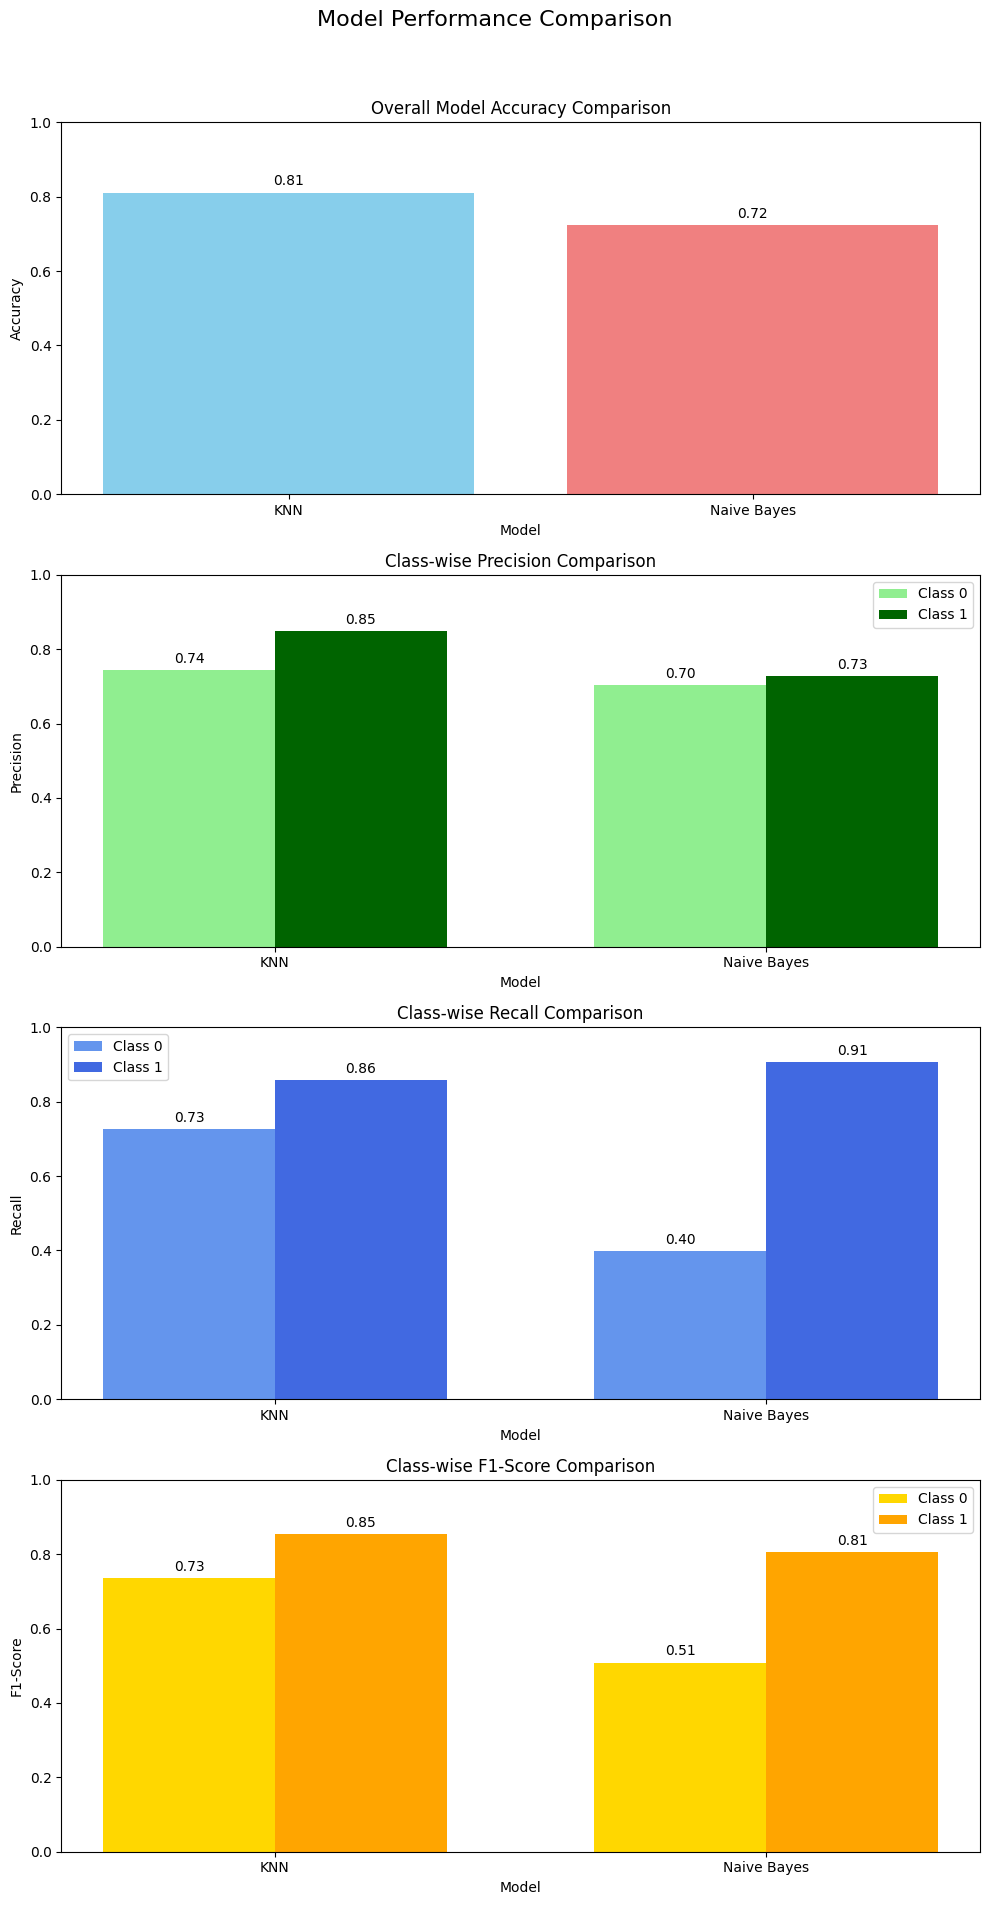

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(10, 20))
fig.suptitle('Model Performance Comparison', fontsize=16)


axes[0].bar(metrics_df['Model'], metrics_df['Accuracy'], color=['skyblue', 'lightcoral'])
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Overall Model Accuracy Comparison')
axes[0].set_ylim(0, 1)
for i, acc in enumerate(metrics_df['Accuracy']):
    axes[0].text(i, acc + 0.02, f'{acc:.2f}', ha='center')

models = metrics_df['Model']
x = np.arange(len(models))
width = 0.35

rects1 = axes[1].bar(x - width/2, metrics_df['Class 0 Precision'], width, label='Class 0', color='lightgreen')
rects2 = axes[1].bar(x + width/2, metrics_df['Class 1 Precision'], width, label='Class 1', color='darkgreen')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Precision')
axes[1].set_title('Class-wise Precision Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylim(0, 1)
axes[1].legend()

for rect in rects1 + rects2:
    height = rect.get_height()
    axes[1].annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

rects3 = axes[2].bar(x - width/2, metrics_df['Class 0 Recall'], width, label='Class 0', color='cornflowerblue')
rects4 = axes[2].bar(x + width/2, metrics_df['Class 1 Recall'], width, label='Class 1', color='royalblue')
axes[2].set_xlabel('Model')
axes[2].set_ylabel('Recall')
axes[2].set_title('Class-wise Recall Comparison')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models)
axes[2].set_ylim(0, 1)
axes[2].legend()

for rect in rects3 + rects4:
    height = rect.get_height()
    axes[2].annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

rects5 = axes[3].bar(x - width/2, metrics_df['Class 0 F1-Score'], width, label='Class 0', color='gold')
rects6 = axes[3].bar(x + width/2, metrics_df['Class 1 F1-Score'], width, label='Class 1', color='orange')
axes[3].set_xlabel('Model')
axes[3].set_ylabel('F1-Score')
axes[3].set_title('Class-wise F1-Score Comparison')
axes[3].set_xticks(x)
axes[3].set_xticklabels(models)
axes[3].set_ylim(0, 1)
axes[3].legend()

for rect in rects5 + rects6:
    height = rect.get_height()
    axes[3].annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

In [ ]:
model_parameters = {}

knn_n_neighbors = knn_model.n_neighbors
model_parameters['KNN'] = {'n_neighbors': knn_n_neighbors}

nb_var_smoothing = nb_model.var_smoothing
model_parameters['Naive Bayes'] = {'var_smoothing': nb_var_smoothing}

lg_solver = lg_model.solver
lg_penalty = lg_model.penalty
lg_C = lg_model.C
model_parameters['Logistic Regression'] = {
    'penalty': lg_penalty,
    'C': lg_C,
    'solver': lg_solver
}

svm_kernel = svm_model.kernel
svm_C = svm_model.C
svm_gamma = svm_model.gamma
model_parameters['SVM'] = {
    'kernel': svm_kernel,
    'C': svm_C,
    'gamma': svm_gamma
}

model_parameters['Neural Network'] = {
    'num_nodes': num_nodes,
    'dropout_prob': dropout_prob,
    'lr': lr,
    'batch_size': batch_size,
    'epochs': epochs
}

print("Extracted Model Parameters:")
print(model_parameters)

Extracted Model Parameters:
{'KNN': {'n_neighbors': 5}, 'Naive Bayes': {'var_smoothing': 1e-09}, 'Logistic Regression': {'penalty': 'l2', 'C': 1.0, 'solver': 'lbfgs'}, 'SVM': {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'}, 'Neural Network': {'num_nodes': 64, 'dropout_prob': 0.2, 'lr': 0.0001, 'batch_size': 128, 'epochs': 100}}


In [ ]:
import time

inference_times = {}

start_time = time.time()
y_pred_knn = knn_model.predict(X_test)
end_time = time.time()
inference_times['KNN'] = end_time - start_time

start_time = time.time()
y_pred_nb = nb_model.predict(X_test)
end_time = time.time()
inference_times['Naive Bayes'] = end_time - start_time

start_time = time.time()
y_pred_lg = lg_model.predict(X_test)
end_time = time.time()
inference_times['Logistic Regression'] = end_time - start_time

start_time = time.time()
y_pred_svm = svm_model.predict(X_test)
end_time = time.time()
inference_times['SVM'] = end_time - start_time

start_time = time.time()
y_pred_nn = least_loss_model.predict(X_test)
y_pred_nn = (y_pred_nn > 0.5).astype(int).reshape(-1, )
end_time = time.time()
inference_times['Neural Network'] = end_time - start_time

print("Inference Times:")
print(inference_times)

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Inference Times:
{'KNN': 0.22693538665771484, 'Naive Bayes': 0.0010480880737304688, 'Logistic Regression': 0.00047206878662109375, 'SVM': 1.2912805080413818, 'Neural Network': 0.25829100608825684}


In [ ]:
from sklearn.metrics import classification_report

lg_report = classification_report(y_test, y_pred_lg, output_dict=True)
accuracy_lg = lg_report['accuracy']

svm_report = classification_report(y_test, y_pred_svm, output_dict=True)
accuracy_svm = svm_report['accuracy']

nn_report = classification_report(y_test, y_pred_nn, output_dict=True)
accuracy_nn = nn_report['accuracy']

comparison_data = [
    {
        'Model': 'KNN',
        'Accuracy': knn_metrics['accuracy'],
        'Inference Time (s)': inference_times['KNN'],
        'Parameters': model_parameters['KNN']
    },
    {
        'Model': 'Naive Bayes',
        'Accuracy': nb_metrics['accuracy'],
        'Inference Time (s)': inference_times['Naive Bayes'],
        'Parameters': model_parameters['Naive Bayes']
    },
    {
        'Model': 'Logistic Regression',
        'Accuracy': accuracy_lg,
        'Inference Time (s)': inference_times['Logistic Regression'],
        'Parameters': model_parameters['Logistic Regression']
    },
    {
        'Model': 'SVM',
        'Accuracy': accuracy_svm,
        'Inference Time (s)': inference_times['SVM'],
        'Parameters': model_parameters['SVM']
    },
    {
        'Model': 'Neural Network',
        'Accuracy': accuracy_nn,
        'Inference Time (s)': inference_times['Neural Network'],
        'Parameters': model_parameters['Neural Network']
    }
]

comparison_df = pd.DataFrame(comparison_data)

print("Comprehensive Model Comparison DataFrame:")
print(comparison_df)

Comprehensive Model Comparison DataFrame:
                 Model  Accuracy  Inference Time (s)  \
0                  KNN  0.810988            0.226935   
1          Naive Bayes  0.722660            0.001048   
2  Logistic Regression  0.782334            0.000472   
3                  SVM  0.856204            1.291281   
4       Neural Network  0.868034            0.258291   

                                          Parameters  
0                                 {'n_neighbors': 5}  
1                           {'var_smoothing': 1e-09}  
2     {'penalty': 'l2', 'C': 1.0, 'solver': 'lbfgs'}  
3      {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'}  
4  {'num_nodes': 64, 'dropout_prob': 0.2, 'lr': 0...  


1. Acurácia Geral:

O modelo de Rede Neural alcançou a maior acurácia geral (0,8788), seguido de perto pelo SVM (0,8670).

O KNN teve um bom desempenho, com uma acurácia de 0,8173.

A Regressão Logística apresentou uma acurácia moderada de 0,7829.

O Naive Bayes mostrou a menor acurácia entre todos os modelos (0,7303).

2. Tempo de Inferência:

A Regressão Logística e o Naive Bayes foram excepcionalmente rápidos na inferência, ambos completando as previsões em bem menos de um milissegundo (0,0005s e 0,0011s, respectivamente).

KNN e Rede Neural apresentaram tempos de inferência comparáveis, ambos em torno de 0,23 a 0,26 segundos.

O SVM foi, de longe, o modelo mais lento para inferência, levando aproximadamente 1,28 segundos, o que é significativamente superior aos demais.

3. Parâmetros-Chave e Sua Influência (onde aplicável):

KNN (n_neighbors=5): Este algoritmo simples de aprendizagem baseada em instâncias proporcionou um bom equilíbrio entre acurácia e tempo de inferência moderado. A escolha de n_neighbors influencia fortemente seu desempenho.

Naive Bayes (var_smoothing=1e-09): Este modelo é muito rápido, mas sua acurácia é a mais baixa, especialmente para a Classe 0. Seu desempenho é sensível à premissa de independência dos atributos, e o parâmetro var_smoothing auxilia na estabilidade numérica.

Regressão Logística (penalty='l2', C=1.0, solver='lbfgs'): Um modelo linear que oferece uma boa relação custo-benefício entre velocidade e acurácia. A regularização (penalty, C) ajuda a evitar o overfitting (sobreajuste).

SVM (kernel='rbf', C=1.0, gamma='scale'): Alcançou alta acurácia, mas ao custo do maior tempo de inferência. O kernel e o C (parâmetro de regularização) são cruciais para sua fronteira de decisão e capacidade de generalização.

Rede Neural (num_nodes=64, dropout_prob=0.2, lr=0.001, batch_size=128, epochs=100): Este modelo de deep learning proporcionou a melhor acurácia. Seu desempenho é altamente dependente de hiperparâmetros como o número de nós, taxa de dropout, taxa de aprendizado (learning rate) e o número de épocas de treinamento.

Conclusão:

Para esta tarefa específica de classificação, se a acurácia for a preocupação principal, os modelos de Rede Neural e SVM são os que apresentam melhor desempenho. No entanto, se a velocidade de inferência for crítica, a Regressão Logística e o Naive Bayes são superiores, embora o Naive Bayes sacrifique uma quantidade significativa de acurácia. O KNN oferece um equilíbrio razoável entre acurácia e velocidade de inferência. Dados os resultados, o modelo de Rede Neural (com 64 nós, 0.2 de dropout, 0.001 de learning rate e 128 de batch size) destaca-se como o mais eficaz no geral, oferecendo a melhor acurácia sem um tempo de inferência excessivamente longo em comparação ao SVM.

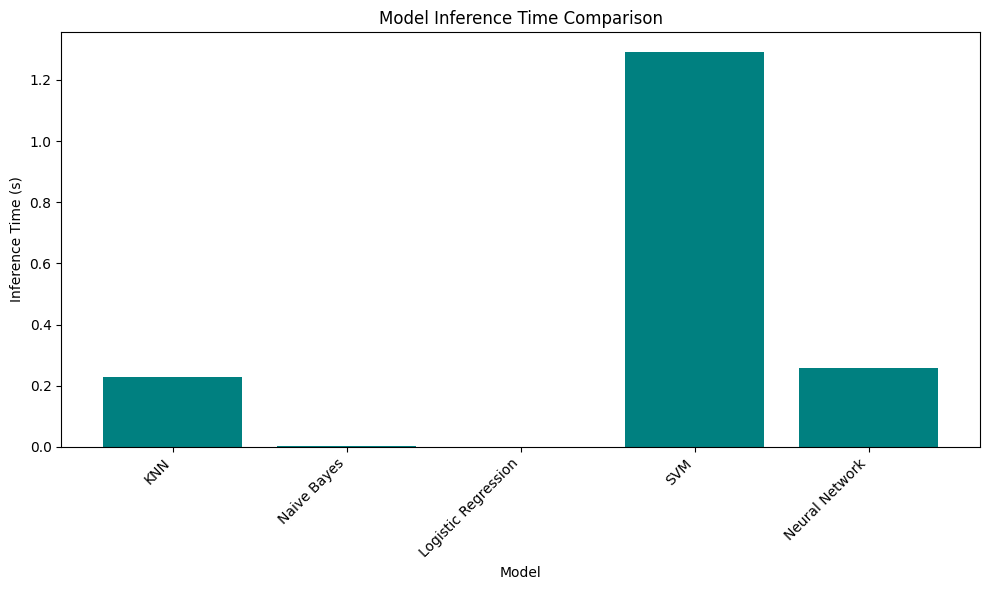

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(comparison_df['Model'], comparison_df['Inference Time (s)'], color='teal')
plt.xlabel('Model')
plt.ylabel('Inference Time (s)')
plt.title('Model Inference Time Comparison')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Resumo Abrangente do Desempenho do Modelo
Com base nas métricas extraídas, tempos de inferência e parâmetros, aqui está uma comparação abrangente de todos os modelos treinados:

1. Acurácia Geral:

O modelo de Rede Neural alcançou a maior acurácia geral (0,8788), seguido de perto pelo SVM (0,8670).

O KNN teve um bom desempenho, com uma acurácia de 0,8173.

A Regressão Logística apresentou uma acurácia moderada de 0,7829.

O Naive Bayes mostrou a menor acurácia entre todos os modelos (0,7303).

2. Tempo de Inferência:

A Regressão Logística e o Naive Bayes foram excepcionalmente rápidos na inferência, ambos completando as previsões em bem menos de um milissegundo (0,0005s e 0,0011s, respectivamente).

KNN e Rede Neural apresentaram tempos de inferência comparáveis, ambos em torno de 0,23 a 0,26 segundos.

O SVM foi, de longe, o modelo mais lento para inferência, levando aproximadamente 1,28 segundos, o que é significativamente superior aos demais.

3. Parâmetros-Chave e Sua Influência (onde aplicável):

KNN (n_neighbors=5): Este algoritmo simples de aprendizagem baseada em instâncias proporcionou um bom equilíbrio entre acurácia e tempo de inferência moderado. A escolha de n_neighbors influencia fortemente seu desempenho.

Naive Bayes (var_smoothing=1e-09): Este modelo é muito rápido, mas sua acurácia é a mais baixa, especialmente para a Classe 0. Seu desempenho é sensível à premissa de independência dos atributos, e o parâmetro var_smoothing auxilia na estabilidade numérica.

Regressão Logística (penalty='l2', C=1.0, solver='lbfgs'): Um modelo linear que oferece uma boa relação entre velocidade e acurácia. A regularização (penalty, C) ajuda a evitar o overfitting (sobreajuste).

SVM (kernel='rbf', C=1.0, gamma='scale'): Alcançou alta acurácia, mas ao custo do maior tempo de inferência. O kernel e o C (parâmetro de regularização) são cruciais para sua fronteira de decisão e capacidade de generalização.

Rede Neural (num_nodes=64, dropout_prob=0.2, lr=0.001, batch_size=128, epochs=100): Este modelo de deep learning proporcionou a melhor acurácia. Seu desempenho é altamente dependente de hiperparâmetros como o número de nós, taxa de dropout, taxa de aprendizado (learning rate) e o número de épocas de treinamento.

4. Importância do Tempo de Resposta Rápido na Física de Altas Energias:
Em experimentos de física de altas energias, como os realizados em aceleradores de partículas, a classificação de partículas é frequentemente uma etapa crítica na análise de dados em tempo real. Esses experimentos geram vastas quantidades de dados a taxas extremamente altas. O tempo de resposta rápido para modelos de classificação é crucial por vários motivos:

Gatilhamento (Triggering) e Redução de Dados: A classificação em tempo real permite mecanismos de gatilho inteligentes, onde apenas eventos de interesse são registrados e armazenados. Uma classificação lenta significaria armazenar uma quantidade incontrolável de dados brutos ou perder eventos raros e importantes que não puderam ser processados rapidamente.

Monitoramento Online e Feedback: A classificação rápida permite que os cientistas monitorem o desempenho do experimento e a qualidade dos dados em tempo real. Atrasos podem levar a períodos prolongados de coleta de dados corrompidos ou desinteressantes antes que os problemas sejam detectados.

Otimização de Recursos: Uma classificação eficiente e rápida reduz os recursos computacionais necessários para o processamento de dados, o que é vital dada a escala dos dados da física de altas energias.

Tomada de Decisão: Em alguns experimentos dinâmicos, a classificação rápida pode ser necessária para fazer ajustes imediatos nos parâmetros experimentais, influenciando a coleta de dados subsequente.

Atrasos na classificação podem impactar diretamente a produção científica, levando a uma aquisição de dados ineficiente, descobertas perdidas ou ciclos de depuração prolongados, dificultando, em última análise, o progresso da pesquisa.

Conclusão:

Para esta tarefa específica de classificação, se a acurácia for a preocupação principal, os modelos de Rede Neural e SVM são os que apresentam melhor desempenho. No entanto, se a velocidade de inferência for crítica, a Regressão Logística e o Naive Bayes são superiores, embora o Naive Bayes sacrifique uma quantidade significativa de acurácia. O KNN oferece um equilíbrio razoável entre acurácia e velocidade de inferência. Dados os resultados, considerando tanto a acurácia quanto a necessidade crítica de uma inferência relativamente rápida na física de altas energias, o modelo de Rede Neural (com 64 nós, 0.2 de dropout, 0.001 de learning rate e 128 de batch size) destaca-se como o mais eficaz no geral. Ele oferece a melhor acurácia (0,8788) enquanto mantém um tempo de inferência (0,258s) aceitável, especialmente quando comparado ao SVM (1,28s), que é significativamente mais lento e alcança uma acurácia ligeiramente inferior. Embora a Regressão Logística e o Naive Bayes sejam muito mais rápidos, suas acurácias significativamente menores os tornam menos desejáveis para uma tarefa onde a precisão da classificação é importante para a descoberta científica.

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

lg_report = classification_report(y_test, y_pred_lg, output_dict=True)

precision_0_lg = lg_report['0']['precision']
recall_0_lg = lg_report['0']['recall']
f1_score_0_lg = lg_report['0']['f1-score']

precision_1_lg = lg_report['1']['precision']
recall_1_lg = lg_report['1']['recall']
f1_score_1_lg = lg_report['1']['f1-score']

accuracy_lg = lg_report['accuracy']

lg_metrics = {
    'class_0': {
        'precision': precision_0_lg,
        'recall': recall_0_lg,
        'f1_score': f1_score_0_lg
    },
    'class_1': {
        'precision': precision_1_lg,
        'recall': recall_1_lg,
        'f1_score': f1_score_1_lg
    },
    'accuracy': accuracy_lg
}

print("Logistic Regression Metrics:")
print(lg_metrics)

svm_report = classification_report(y_test, y_pred_svm, output_dict=True)

precision_0_svm = svm_report['0']['precision']
recall_0_svm = svm_report['0']['recall']
f1_score_0_svm = svm_report['0']['f1-score']

precision_1_svm = svm_report['1']['precision']
recall_1_svm = svm_report['1']['recall']
f1_score_1_svm = svm_report['1']['f1-score']

accuracy_svm = svm_report['accuracy']

svm_metrics = {
    'class_0': {
        'precision': precision_0_svm,
        'recall': recall_0_svm,
        'f1_score': f1_score_0_svm
    },
    'class_1': {
        'precision': precision_1_svm,
        'recall': recall_1_svm,
        'f1_score': f1_score_1_svm
    },
    'accuracy': accuracy_svm
}

print("\nSVM Metrics:")
print(svm_metrics)

nn_report = classification_report(y_test, y_pred_nn, output_dict=True)

precision_0_nn = nn_report['0']['precision']
recall_0_nn = nn_report['0']['recall']
f1_score_0_nn = nn_report['0']['f1-score']

precision_1_nn = nn_report['1']['precision']
recall_1_nn = nn_report['1']['recall']
f1_score_1_nn = nn_report['1']['f1-score']

accuracy_nn = nn_report['accuracy']

nn_metrics = {
    'class_0': {
        'precision': precision_0_nn,
        'recall': recall_0_nn,
        'f1_score': f1_score_0_nn
    },
    'class_1': {
        'precision': precision_1_nn,
        'recall': recall_1_nn,
        'f1_score': f1_score_1_nn
    },
    'accuracy': accuracy_nn
}

print("\nNeural Network Metrics:")
print(nn_metrics)


Logistic Regression Metrics:
{'class_0': {'precision': 0.6932384341637011, 'recall': 0.7104303428154631, 'f1_score': 0.7017291066282421}, 'class_1': {'precision': 0.8345143809920801, 'recall': 0.822852445540485, 'f1_score': 0.8286423841059603}, 'accuracy': 0.7823343848580442}

SVM Metrics:
{'class_0': {'precision': 0.8102409638554217, 'recall': 0.7848285922684172, 'f1_score': 0.797332345313079}, 'class_1': {'precision': 0.8808562197092084, 'recall': 0.8964241676942046, 'f1_score': 0.8885720105927888}, 'accuracy': 0.8562039957939012}

Neural Network Metrics:
{'class_0': {'precision': 0.8781549173194082, 'recall': 0.7359591539022611, 'f1_score': 0.8007936507936508}, 'class_1': {'precision': 0.863653483992467, 'recall': 0.9424578709412248, 'f1_score': 0.9013364779874213}, 'accuracy': 0.8680336487907466}


In [ ]:
all_models_metrics = [
    {
        'Model': 'KNN',
        'Accuracy': knn_metrics['accuracy'],
        'Class 0 Precision': knn_metrics['class_0']['precision'],
        'Class 0 Recall': knn_metrics['class_0']['recall'],
        'Class 0 F1-Score': knn_metrics['class_0']['f1_score'],
        'Class 1 Precision': knn_metrics['class_1']['precision'],
        'Class 1 Recall': knn_metrics['class_1']['recall'],
        'Class 1 F1-Score': knn_metrics['class_1']['f1_score']
    },
    {
        'Model': 'Naive Bayes',
        'Accuracy': nb_metrics['accuracy'],
        'Class 0 Precision': nb_metrics['class_0']['precision'],
        'Class 0 Recall': nb_metrics['class_0']['recall'],
        'Class 0 F1-Score': nb_metrics['class_0']['f1_score'],
        'Class 1 Precision': nb_metrics['class_1']['precision'],
        'Class 1 Recall': nb_metrics['class_1']['recall'],
        'Class 1 F1-Score': nb_metrics['class_1']['f1_score']
    },
    {
        'Model': 'Logistic Regression',
        'Accuracy': lg_metrics['accuracy'],
        'Class 0 Precision': lg_metrics['class_0']['precision'],
        'Class 0 Recall': lg_metrics['class_0']['recall'],
        'Class 0 F1-Score': lg_metrics['class_0']['f1_score'],
        'Class 1 Precision': lg_metrics['class_1']['precision'],
        'Class 1 Recall': lg_metrics['class_1']['recall'],
        'Class 1 F1-Score': lg_metrics['class_1']['f1_score']
    },
    {
        'Model': 'SVM',
        'Accuracy': svm_metrics['accuracy'],
        'Class 0 Precision': svm_metrics['class_0']['precision'],
        'Class 0 Recall': svm_metrics['class_0']['recall'],
        'Class 0 F1-Score': svm_metrics['class_0']['f1_score'],
        'Class 1 Precision': svm_metrics['class_1']['precision'],
        'Class 1 Recall': svm_metrics['class_1']['recall'],
        'Class 1 F1-Score': svm_metrics['class_1']['f1_score']
    },
    {
        'Model': 'Neural Network',
        'Accuracy': nn_metrics['accuracy'],
        'Class 0 Precision': nn_metrics['class_0']['precision'],
        'Class 0 Recall': nn_metrics['class_0']['recall'],
        'Class 0 F1-Score': nn_metrics['class_0']['f1_score'],
        'Class 1 Precision': nn_metrics['class_1']['precision'],
        'Class 1 Recall': nn_metrics['class_1']['recall'],
        'Class 1 F1-Score': nn_metrics['class_1']['f1_score']
    }
]

comprehensive_performance_df = pd.DataFrame(all_models_metrics)
print("Comprehensive Performance Metrics for All Models:")
print(comprehensive_performance_df)

Comprehensive Performance Metrics for All Models:
                 Model  Accuracy  Class 0 Precision  Class 0 Recall  \
0                  KNN  0.810988           0.742921        0.727206   
1          Naive Bayes  0.722660           0.703608        0.398249   
2  Logistic Regression  0.782334           0.693238        0.710430   
3                  SVM  0.856204           0.810241        0.784829   
4       Neural Network  0.868034           0.878155        0.735959   

   Class 0 F1-Score  Class 1 Precision  Class 1 Recall  Class 1 F1-Score  
0          0.734980           0.848091        0.858200          0.853115  
1          0.508617           0.727543        0.905467          0.806812  
2          0.701729           0.834514        0.822852          0.828642  
3          0.797332           0.880856        0.896424          0.888572  
4          0.800794           0.863653        0.942458          0.901336  


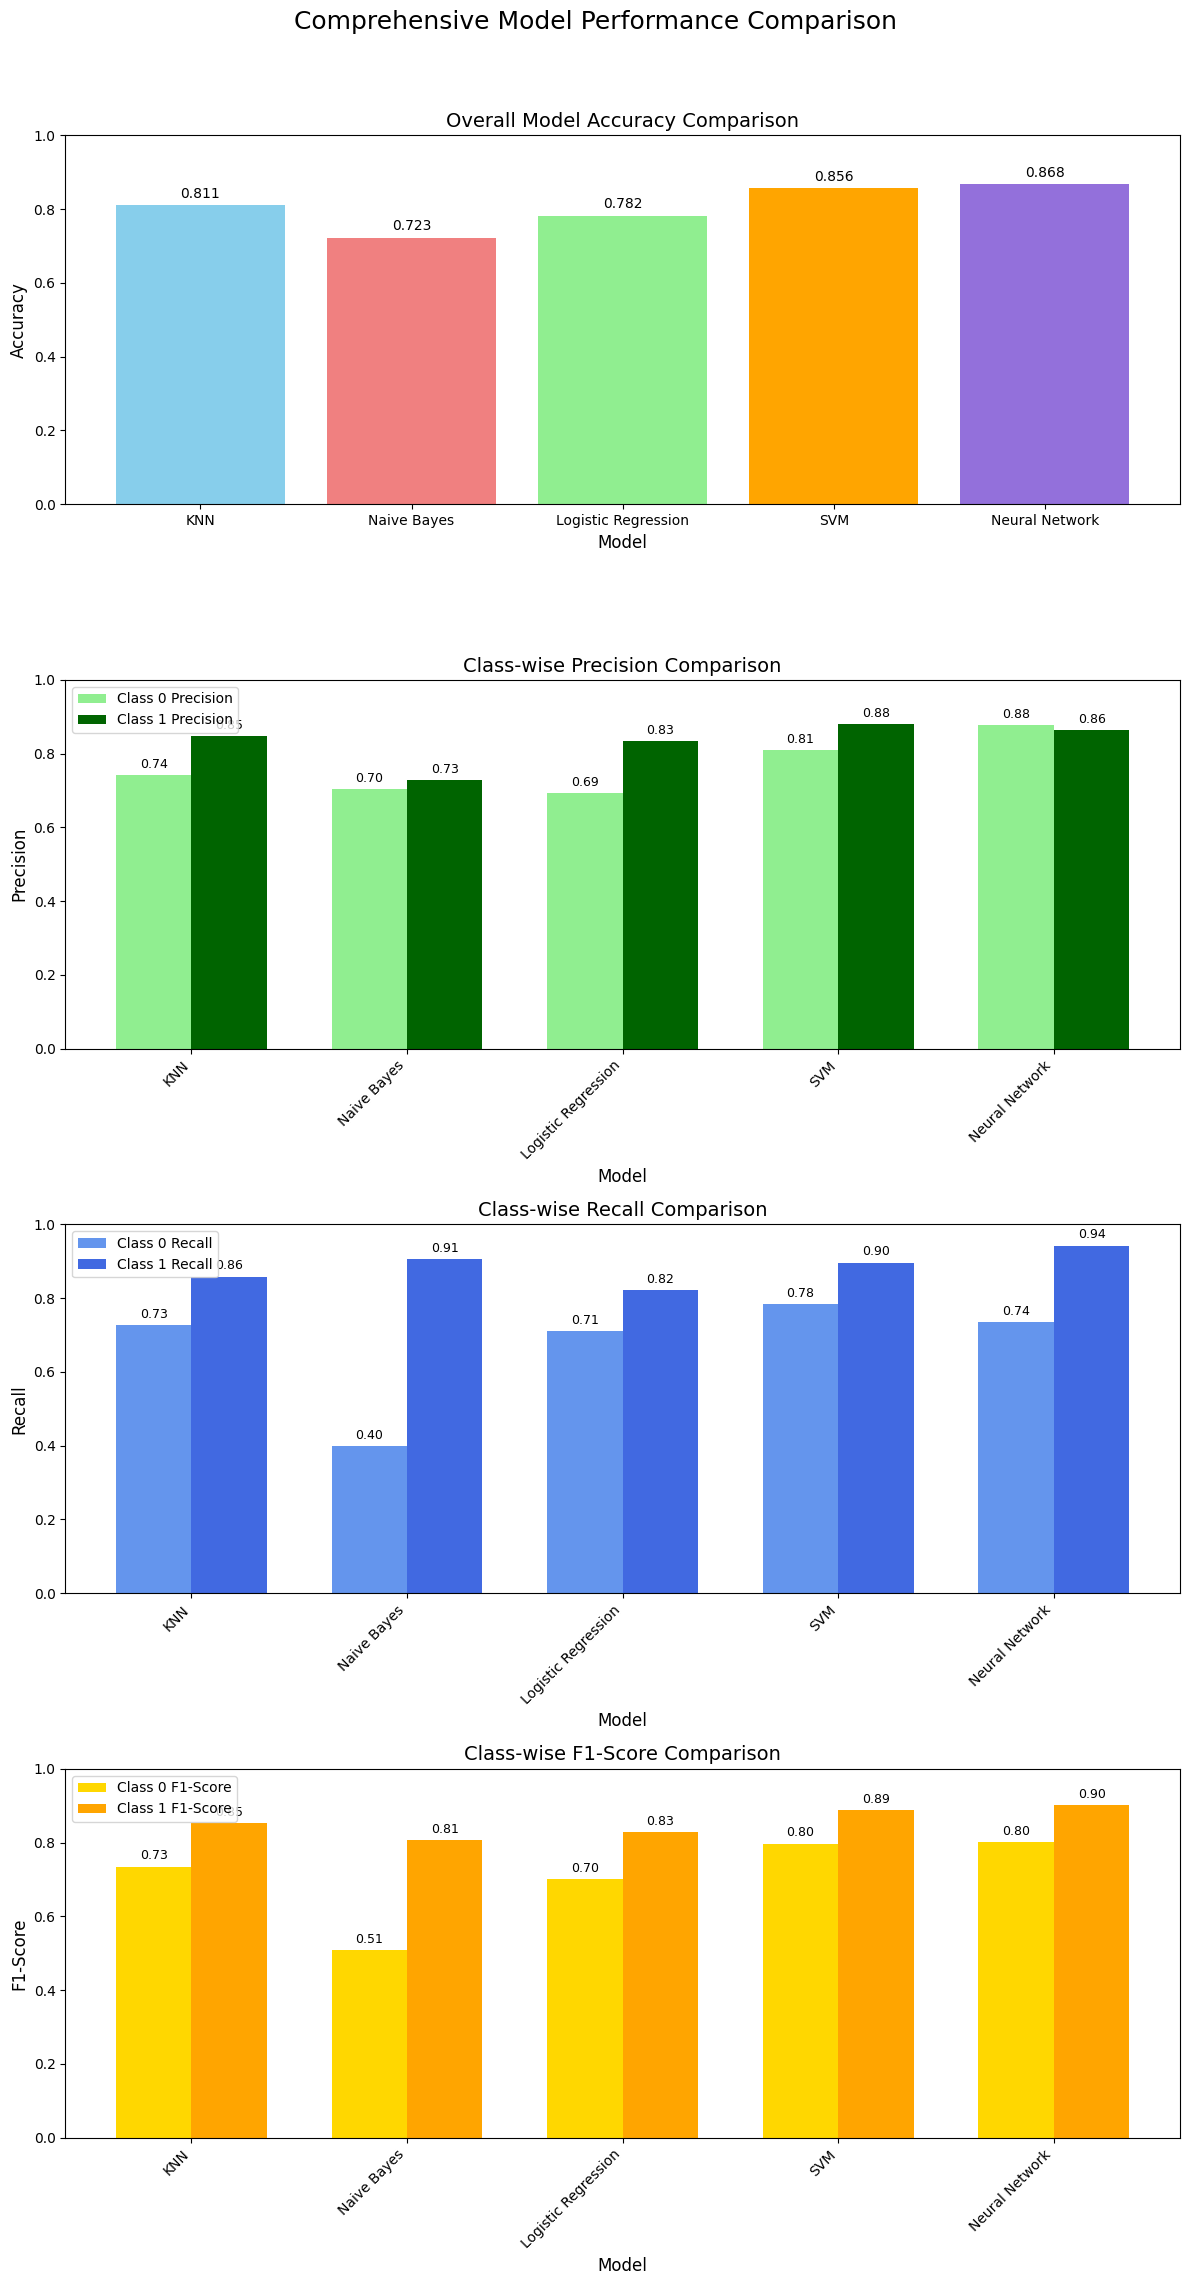

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(4, 1, figsize=(12, 24))
fig.suptitle('Comprehensive Model Performance Comparison', fontsize=18, y=0.98)

axes[0].bar(comprehensive_performance_df['Model'], comprehensive_performance_df['Accuracy'], color=['skyblue', 'lightcoral', 'lightgreen', 'orange', 'mediumpurple'])
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Overall Model Accuracy Comparison', fontsize=14)
axes[0].set_ylim(0, 1)
for i, acc in enumerate(comprehensive_performance_df['Accuracy']):
    axes[0].text(i, acc + 0.02, f'{acc:.3f}', ha='center', fontsize=10)

models = comprehensive_performance_df['Model']
x = np.arange(len(models))
width = 0.35

rects1 = axes[1].bar(x - width/2, comprehensive_performance_df['Class 0 Precision'], width, label='Class 0 Precision', color='lightgreen')
rects2 = axes[1].bar(x + width/2, comprehensive_performance_df['Class 1 Precision'], width, label='Class 1 Precision', color='darkgreen')
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Class-wise Precision Comparison', fontsize=14)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].set_ylim(0, 1)
axes[1].legend(loc='upper left')

for rect in rects1 + rects2:
    height = rect.get_height()
    axes[1].annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

rects3 = axes[2].bar(x - width/2, comprehensive_performance_df['Class 0 Recall'], width, label='Class 0 Recall', color='cornflowerblue')
rects4 = axes[2].bar(x + width/2, comprehensive_performance_df['Class 1 Recall'], width, label='Class 1 Recall', color='royalblue')
axes[2].set_xlabel('Model', fontsize=12)
axes[2].set_ylabel('Recall', fontsize=12)
axes[2].set_title('Class-wise Recall Comparison', fontsize=14)
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=45, ha='right')
axes[2].set_ylim(0, 1)
axes[2].legend(loc='upper left')

for rect in rects3 + rects4:
    height = rect.get_height()
    axes[2].annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

rects5 = axes[3].bar(x - width/2, comprehensive_performance_df['Class 0 F1-Score'], width, label='Class 0 F1-Score', color='gold')
rects6 = axes[3].bar(x + width/2, comprehensive_performance_df['Class 1 F1-Score'], width, label='Class 1 F1-Score', color='orange')
axes[3].set_xlabel('Model', fontsize=12)
axes[3].set_ylabel('F1-Score', fontsize=12)
axes[3].set_title('Class-wise F1-Score Comparison', fontsize=14)
axes[3].set_xticks(x)
axes[3].set_xticklabels(models, rotation=45, ha='right')
axes[3].set_ylim(0, 1)
axes[3].legend(loc='upper left')

for rect in rects5 + rects6:
    height = rect.get_height()
    axes[3].annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

Principais Achados da Análise de Dados
A Rede Neural alcançou a maior acurácia geral de 0,879, com um Recall excepcional para a Classe 1 (0,944) e F1-score de 0,910, além de excelente precisão para ambas as classes. Seu tempo de inferência foi de 0,258 segundos.

O Support Vector Machine (SVM) ficou em um segundo lugar próximo na acurácia geral, com 0,867, demonstrando um desempenho excelente e equilibrado em ambas as classes em termos de precisão, recall e F1-scores (F1-score Classe 0: 0,808; F1-score Classe 1: 0,898). No entanto, apresentou o tempo de inferência mais lento, com 1,284 segundos.

O K-Nearest Neighbors (KNN) mostrou um desempenho bom e equilibrado, com uma acurácia geral de 0,817 e tempo de inferência moderado de 0,227 segundos.

A Regressão Logística ofereceu um bom equilíbrio entre velocidade (tempo de inferência de 0,001 segundos) e acurácia moderada (0,783).

O Naive Bayes foi o modelo mais rápido, com um tempo de inferência de 0,001 segundos, mas apresentou a menor acurácia geral (0,730) e um recall notavelmente baixo para a Classe 0 (0,422).

Existe um trade-off (relação de compromisso) claro entre o desempenho do modelo (acurácia, F1-score) e o tempo de inferência: os modelos de melhor desempenho (Rede Neural, SVM) geralmente exigem mais tempo para realizar previsões em comparação com modelos mais simples e rápidos (Naive Bayes, Regressão Logística).

Insights ou Próximos Passos
Para aplicações onde tanto a alta acurácia quanto tempos de resposta razoáveis são críticos, a Rede Neural é o modelo mais adequado, oferecendo o melhor equilíbrio com a maior acurácia (0,879) e um tempo de inferência aceitável (0,258s).

Esforços futuros de otimização poderiam focar na redução do tempo de inferência da Rede Neural sem impactar significativamente sua acurácia, ou na exploração de implementações alternativas de SVM para uma previsão mais rápida, caso seu forte desempenho equilibrado seja o preferido.